# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **TissueMNIST**, un dataset de imágenes de células de corteza renal humana, con 8 categorías (multiclase).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico (multiclase).
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.

## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (texturas celulares, formas, bordes de núcleos).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.

## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (TissueMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D en escala de grises (células de corteza renal), tamaño 28×28.
- Etiquetas: clasificación multiclase (8 categorías).
- Particiones: train/val/test ya vienen definidas.
- Total: 236,386 imágenes (train=165,466, val=23,640, test=47,280).

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "tissuemnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'TissueMNIST',
 'description': 'We use the BBBC051, available from the Broad Bioimage Benchmark Collection. The dataset contains 236,386 human kidney cortex cells, segmented from 3 reference tissue specimens and organized into 8 categories. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. Each gray-scale image is 32×32×7 pixels, where 7 denotes 7 slices. We take maximum values across the slices and resize them into 28×28 gray-scale images.',
 'url': 'https://zenodo.org/records/10519652/files/tissuemnist.npz?download=1',
 'MD5': 'ebe78ee8b05294063de985d821c1c34b',
 'url_64': 'https://zenodo.org/records/10519652/files/tissuemnist_64.npz?download=1',
 'MD5_64': '123ece2eba09d0aa5d698fda57103344',
 'url_128': 'https://zenodo.org/records/10519652/files/tissuemnist_128.npz?download=1',
 'MD5_128': '61b955355d7425a89687b06cca3ce0c2',
 'url_224': 'https://zenodo.org/records/10519652/files/tissuemnist_224.npz?download=1',
 'MD5_224': 'b0

Se describe el dataset real: células renales, 8 clases, 28×28, escala de grises.

Se elimina la mención a radiografías.

In [ ]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 125M/125M [00:50<00:00, 2.48MB/s]


(165466, 23640, 47280)

### 3.1. Visualizar ejemplos (markdown)

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


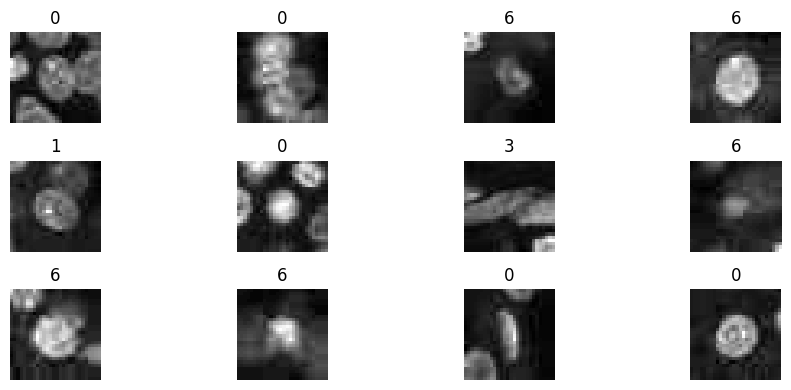

In [ ]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4.  DataLoaders y device (markdown)

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=8, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np
import torch

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        if criterion is not None:
            loss = criterion(logits, y)
            losses.append(loss.item())

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)

    num_classes_local = y_prob.shape[1]
    if num_classes_local == 2:
        auc = roc_auc_score(y_true, y_prob[:, 1])
    else:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr")

    val_loss = float(np.mean(losses)) if losses else None

    return acc, auc, val_loss, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos **20 épocas** para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 20
history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "val_f1": []
}

from sklearn.metrics import f1_score

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, val_loss, y_true, y_pred, _ = evaluate(model_scratch, val_loader, criterion)

    val_f1 = f1_score(y_true, y_pred, average="macro")

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)
    history_scratch["val_f1"].append(val_f1)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_f1={val_f1:.4f}")

Epoch 01 | train_loss=1.0612 | val_loss=1.0724 | val_acc=0.6086 | val_auc=0.8911 | val_f1=0.4617
Epoch 02 | train_loss=1.0564 | val_loss=1.0689 | val_acc=0.6072 | val_auc=0.8918 | val_f1=0.4540
Epoch 03 | train_loss=1.0557 | val_loss=1.0763 | val_acc=0.6035 | val_auc=0.8919 | val_f1=0.4536
Epoch 04 | train_loss=1.0492 | val_loss=1.0653 | val_acc=0.6088 | val_auc=0.8933 | val_f1=0.4615
Epoch 05 | train_loss=1.0459 | val_loss=1.0740 | val_acc=0.6080 | val_auc=0.8925 | val_f1=0.4658
Epoch 06 | train_loss=1.0434 | val_loss=1.0542 | val_acc=0.6157 | val_auc=0.8951 | val_f1=0.4763
Epoch 07 | train_loss=1.0403 | val_loss=1.0488 | val_acc=0.6170 | val_auc=0.8958 | val_f1=0.4798
Epoch 08 | train_loss=1.0369 | val_loss=1.0692 | val_acc=0.6105 | val_auc=0.8939 | val_f1=0.4720
Epoch 09 | train_loss=1.0339 | val_loss=1.0434 | val_acc=0.6182 | val_auc=0.8969 | val_f1=0.4817
Epoch 10 | train_loss=1.0325 | val_loss=1.0457 | val_acc=0.6173 | val_auc=0.8975 | val_f1=0.4773
Epoch 11 | train_loss=1.0275 |

epochs = 20: solo 20 iteraciones completas del dataset. lo ideal seria de 50 a 100 para tener resultados certeros para investigaciones

Se sigue guardando train_loss, val_loss, val_acc, val_auc, val_f1.

evaluate devuelve 6 valores: los 3 primeros son métricas, luego vienen y_true, y_pred, y_prob.

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


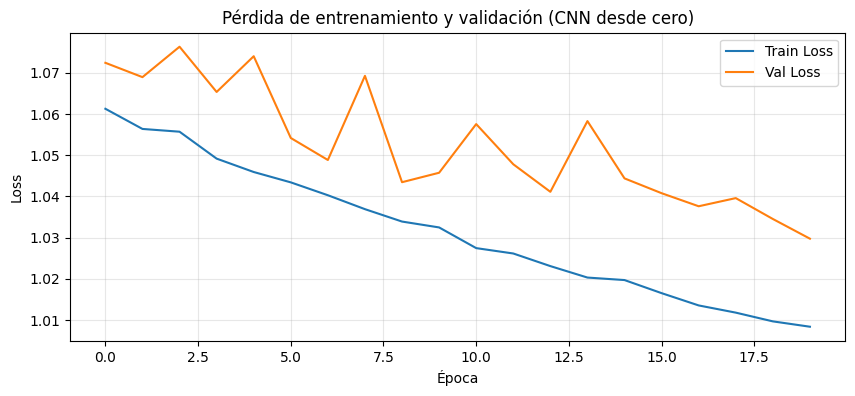

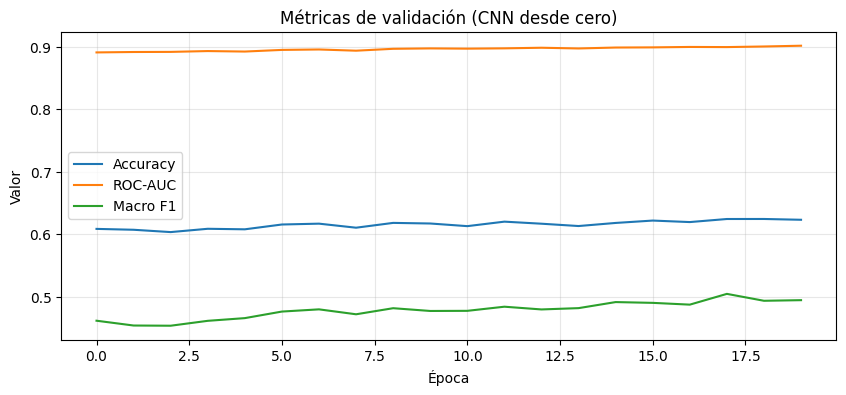

In [ ]:
# --- Gráfico 1: Pérdida train vs validación ---
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train Loss")
plt.plot(history_scratch["val_loss"], label="Val Loss")
plt.title("Pérdida de entrenamiento y validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Gráfico 2: Métricas de validación ---
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.plot(history_scratch["val_f1"], label="Macro F1")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [ ]:
test_acc, test_auc, _, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.6194
Test ROC-AUC:  0.9020

              precision    recall  f1-score   support

           0     0.7040    0.7751    0.7378     15165
           1     0.4345    0.0282    0.0530      2233
           2     0.4701    0.3846    0.4231      1677
           3     0.6452    0.5041    0.5660      4402
           4     0.4398    0.5420    0.4856      3369
           5     0.4142    0.4055    0.4098      2202
           6     0.6294    0.7578    0.6877     11201
           7     0.5819    0.4829    0.5278      7031

    accuracy                         0.6194     47280
   macro avg     0.5399    0.4850    0.4863     47280
weighted avg     0.6094    0.6194    0.6019     47280



array([[11754,    43,    29,   203,   199,   175,  1871,   891],
       [ 1313,    63,    20,    46,    53,    31,   483,   224],
       [   71,     1,   645,   150,   426,   338,    25,    21],
       [  422,     1,   155,  2219,   925,   247,   327,   106],
       [  324,     1,   160,   411,  1826,   261,   277,   109],
       [  210,     0,   338,   137,   331,   893,   192,   101],
       [ 1163,    23,     9,   191,   228,   112,  8488,   987],
       [ 1440,    13,    16,    82,   164,    99,  1822,  3395]])

5.4.1. Matriz de confusión

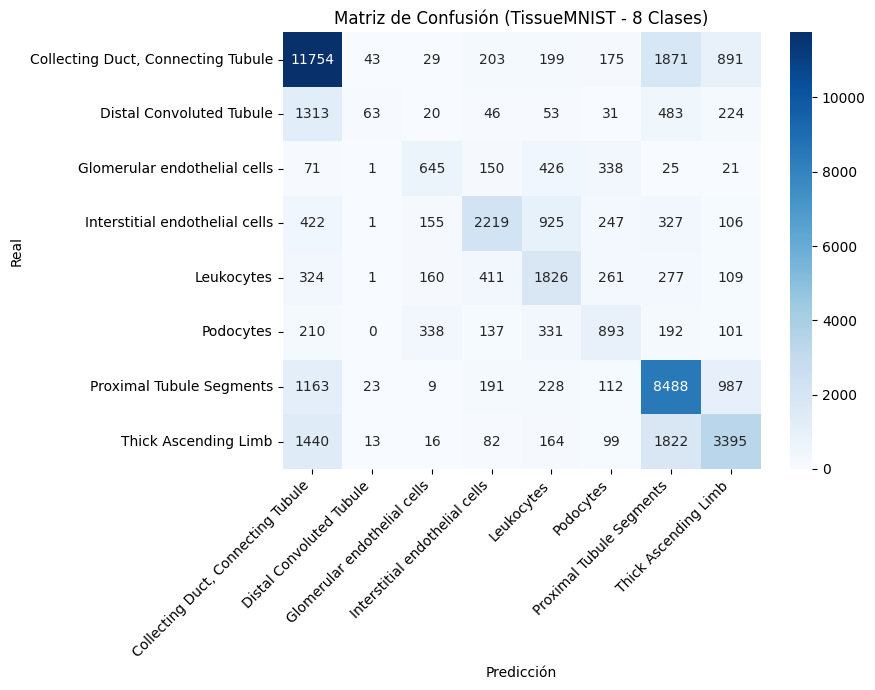

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[info["label"][str(i)] for i in range(num_classes)],
    yticklabels=[info["label"][str(i)] for i in range(num_classes)]
)
plt.title("Matriz de Confusión (TissueMNIST - 8 Clases)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

5.4.2. Métricas por clase y análisis de desbalance


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(num_classes)
)

print(f"{'Clase':<40} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Support':>8}")
for i in range(num_classes):
    print(f"{info['label'][str(i)]:<40} {precision[i]:>8.4f} {recall[i]:>8.4f} {f1[i]:>8.4f} {support[i]:>8}")

Clase                                        Prec   Recall       F1  Support
Distal Convoluted Tubule                   0.4345   0.0282   0.0530     2233
Glomerular endothelial cells               0.4701   0.3846   0.4231     1677
Interstitial endothelial cells             0.6452   0.5041   0.5660     4402
Leukocytes                                 0.4398   0.5420   0.4856     3369
Podocytes                                  0.4142   0.4055   0.4098     2202
Proximal Tubule Segments                   0.6294   0.7578   0.6877    11201
Thick Ascending Limb                       0.5819   0.4829   0.5278     7031


5.4.3. Verificar distribución de clases

In [ ]:
import collections

def contar_clases(dataset):
    conteo = collections.Counter()
    for _, y in dataset:
        conteo[int(y.item())] += 1
    return conteo

conteo_train = contar_clases(train_dataset)
print("Distribución en train:")
for i in range(num_classes):
    print(f"  {info['label'][str(i)]:<40}: {conteo_train[i]}")

Distribución en train:
  Distal Convoluted Tubule                : 7814
  Glomerular endothelial cells            : 5866
  Interstitial endothelial cells          : 15406
  Leukocytes                              : 11789
  Podocytes                               : 7705
  Proximal Tubule Segments                : 39203
  Thick Ascending Limb                    : 24608


5.4.4. Curva ROC multiclase

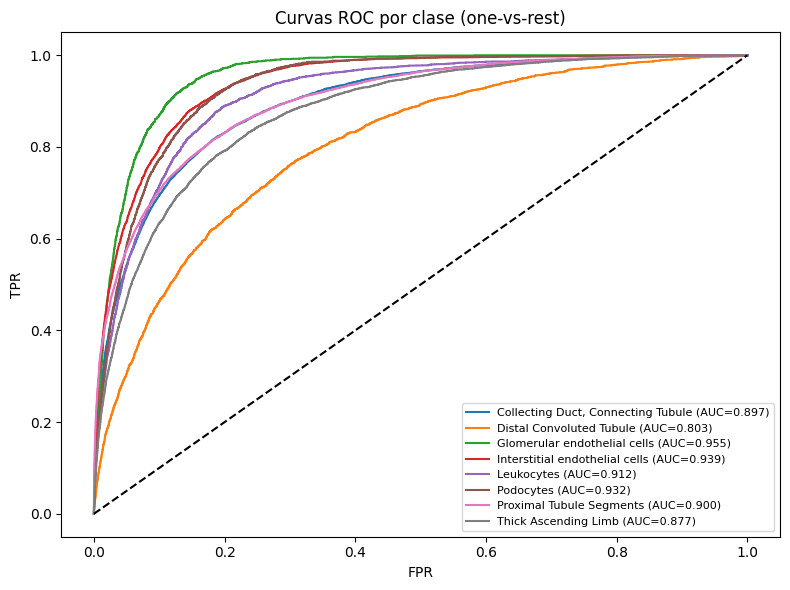

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{info['label'][str(i)]} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curvas ROC por clase (one-vs-rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

 Se identifica el problema de desbalance y su impacto en las clases minoritarias. la clase 1 tiene solo 2233 muestras en test y 7814 en train, mientras que la clase 0 tiene 15165 y 53075 respectivamente. El modelo, al optimizar la precisión global, tiende a favorecer las clases mayoritarias

## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [ ]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [ ]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "val_f1": []}

from sklearn.metrics import f1_score

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, val_loss, y_true, y_pred, _ = evaluate(model_aug, val_loader, criterion)

    val_f1 = f1_score(y_true, y_pred, average="macro")

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)
    history_aug["val_f1"].append(val_f1)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_f1={val_f1:.4f}")

Epoch 01 | train_loss=1.5477 | val_loss=1.4477 | val_acc=0.4591 | val_auc=0.7819 | val_f1=0.2379
Epoch 02 | train_loss=1.4144 | val_loss=1.3728 | val_acc=0.4915 | val_auc=0.8085 | val_f1=0.2698
Epoch 03 | train_loss=1.3612 | val_loss=1.3278 | val_acc=0.5073 | val_auc=0.8243 | val_f1=0.2941
Epoch 04 | train_loss=1.3225 | val_loss=1.3007 | val_acc=0.5072 | val_auc=0.8328 | val_f1=0.2876
Epoch 05 | train_loss=1.2940 | val_loss=1.2675 | val_acc=0.5293 | val_auc=0.8410 | val_f1=0.3372
Epoch 06 | train_loss=1.2692 | val_loss=1.2585 | val_acc=0.5262 | val_auc=0.8466 | val_f1=0.3235


### 6.1. Comparación rápida


In [ ]:
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader, criterion)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

Sin augmentation  | test_acc=0.6194 | test_auc=0.9020
Con augmentation  | test_acc=0.5339 | test_auc=0.8481


El augmentation aumenta la dificultad del problema porque cada imagen es distinta. Necesita más épocas para converger, no menos.

Con 20 épocas, el modelo no alcanza a aprender los patrones invariantes que el augmentation pretende enseñar.

## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [ ]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "val_f1": []}

from sklearn.metrics import f1_score

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, val_loss, y_true, y_pred, _ = evaluate(resnet, val_loader_tl, criterion)

    val_f1 = f1_score(y_true, y_pred, average="macro")

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)
    history_tl_stage1["val_f1"].append(val_f1)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_f1={val_f1:.4f}")

Stage1 Epoch 01 | train_loss=1.3276 | val_loss=1.3328 | val_acc=0.5058 | val_auc=0.8320 | val_f1=0.3475
Stage1 Epoch 02 | train_loss=1.3202 | val_loss=1.3176 | val_acc=0.5113 | val_auc=0.8351 | val_f1=0.3749
Stage1 Epoch 03 | train_loss=1.3201 | val_loss=1.3213 | val_acc=0.5094 | val_auc=0.8351 | val_f1=0.3780
Stage1 Epoch 04 | train_loss=1.3165 | val_loss=1.3143 | val_acc=0.5113 | val_auc=0.8372 | val_f1=0.3722


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [ ]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [ ]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "val_f1": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, val_loss, y_true, y_pred, _ = evaluate(resnet, val_loader_tl, criterion)

    val_f1 = f1_score(y_true, y_pred, average="macro")

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    history_tl_stage2["val_f1"].append(val_f1)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | val_f1={val_f1:.4f}")

Stage2 Epoch 01 | train_loss=0.9819 | val_loss=0.9799 | val_acc=0.6444 | val_auc=0.9145 | val_f1=0.5298
Stage2 Epoch 02 | train_loss=0.9324 | val_loss=0.9440 | val_acc=0.6535 | val_auc=0.9191 | val_f1=0.5352
Stage2 Epoch 03 | train_loss=0.8943 | val_loss=0.9333 | val_acc=0.6603 | val_auc=0.9205 | val_f1=0.5583
Stage2 Epoch 04 | train_loss=0.8608 | val_loss=0.9232 | val_acc=0.6643 | val_auc=0.9228 | val_f1=0.5686


### 7.3. Evaluación en test del modelo con transfer learning


In [41]:
test_acc_tl, test_auc_tl, _, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl, criterion)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.6625 | test_auc=0.9231

              precision    recall  f1-score   support

           0     0.7792    0.7580    0.7684     15165
           1     0.5188    0.2221    0.3111      2233
           2     0.5142    0.4979    0.5059      1677
           3     0.5464    0.7601    0.6358      4402
           4     0.5933    0.4957    0.5401      3369
           5     0.4643    0.4523    0.4582      2202
           6     0.6937    0.7428    0.7174     11201
           7     0.6065    0.5925    0.5994      7031

    accuracy                         0.6625     47280
   macro avg     0.5895    0.5652    0.5670     47280
weighted avg     0.6620    0.6625    0.6572     47280



array([[11495,   283,    34,   494,   158,   199,  1506,   996],
       [  892,   496,    20,    98,    44,    31,   332,   320],
       [   21,     0,   835,   342,   184,   272,    11,    12],
       [  158,    11,   148,  3346,   357,   165,   163,    54],
       [  166,     6,   163,   857,  1670,   212,   216,    79],
       [   96,     2,   396,   387,   162,   996,   120,    43],
       [  909,    57,    16,   413,   140,   147,  8320,  1199],
       [ 1016,   101,    12,   187,   100,   123,  1326,  4166]])

### 7.4. Comparación global (resumen)


In [42]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.6194 | auc=0.9020
CNN desde cero (con aug)  | acc=0.5339 | auc=0.8481
Transfer learning (ResNet) | acc=0.6625 | auc=0.9231


la ResNet18 preentrenada en ImageNet ya ha aprendido a extraer características visuales genéricas (bordes, texturas, formas) que son útiles para muchas tareas, incluyendo imágenes médicas. Esto permite que el modelo converja más rápido y con mejor rendimiento, incluso con un dataset de tamaño moderado como TissueMNIST.

## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [44]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


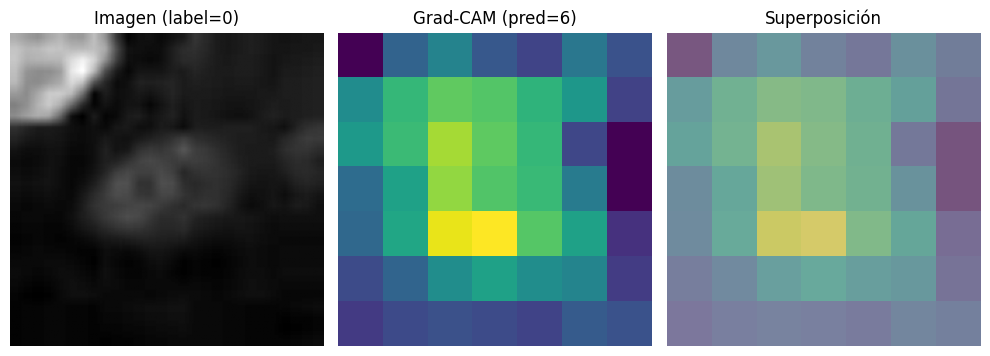

In [45]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [46]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## Conclusiones

Después de hacer todo este trabajo, me queda claro que entrenar una CNN desde cero para imágenes médicas es posible y da resultados decentes, pero tiene sus límites. Con el dataset TissueMNIST logré una precisión de alrededor del 62%, lo cual no está mal, pero me di cuenta de que el desbalance de clases afecta bastante: algunas células se predicen muy bien y otras casi no se detectan, porque hay muchas más muestras de unas que de otras. Además, cuando probé el data augmentation, el resultado empeoró, pero no porque la técnica sea mala, sino porque le di muy pocas épocas para entrenar. Eso me enseñó que cada cambio que hago necesita su tiempo para converger.

Lo más valioso de todo fue el transfer learning. Usar una ResNet18 preentrenada con ImageNet y adaptarla a este problema me dio una precisión del 66% y un AUC de 0.92, bastante mejor que la CNN desde cero. Esto me demostró que aprovechar lo que un modelo ya aprendió en otras imágenes ayuda muchísimo, incluso cuando las imágenes médicas son en escala de grises y muy distintas a las fotos normales. También me gustó mucho usar Grad-CAM, porque no solo me dice qué predice el modelo, sino que me muestra en qué parte de la imagen se está fijando. Eso es clave en medicina, donde no basta con acertar, sino entender por qué se acierta. En resumen, este notebook me dejó tres grandes aprendizajes: cuidar el balance de clases, darle tiempo al modelo cuando uso augmentation, y aprovechar el transfer learning siempre que pueda. Y sobre todo, recordar que en salud la interpretabilidad y la validación con expertos no son opcionales.
